In [42]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [43]:
# Ajustar exibição do Pandas para ver todas as colunas
pd.set_option('display.max_columns', None)

In [44]:
# 1. Carregar o dataset
try:
    df = pd.read_csv('../data/UCI_Credit_Card.csv')
    print("Dataset carregado com sucesso!")
except FileNotFoundError:
    df = pd.read_csv('data/UCI_Credit_Card.csv')
    print("Dataset carregado com sucesso (da raiz)!")

Dataset carregado com sucesso!


In [45]:
# 2. Informações Gerais
print(f"\nDimensões do Dataset: {df.shape[0]} linhas e {df.shape[1]} colunas.")
print("\n--- Primeiras 5 linhas ---")
display(df.head())


Dimensões do Dataset: 30000 linhas e 25 colunas.

--- Primeiras 5 linhas ---


,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
0,1,20000.0,2,2,1,24,2,2,-1,-1,-2,-2,3913.0,3102.0,689.0,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1
1,2,120000.0,2,2,2,26,-1,2,0,0,0,2,2682.0,1725.0,2682.0,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1
2,3,90000.0,2,2,2,34,0,0,0,0,0,0,29239.0,14027.0,13559.0,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0
3,4,50000.0,2,2,1,37,0,0,0,0,0,0,46990.0,48233.0,49291.0,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0
4,5,50000.0,1,2,1,57,-1,0,-1,0,0,0,8617.0,5670.0,35835.0,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0


In [46]:
print("\n--- Tipos de Dados e Ausentes ---")
print(df.info())

print("\n--- Contagem de Valores Nulos por Coluna ---")
print(df.isnull().sum().sum(), "valores nulos encontrados no total.")


--- Tipos de Dados e Ausentes ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   ID                          30000 non-null  int64  
 1   LIMIT_BAL                   30000 non-null  float64
 2   SEX                         30000 non-null  int64  
 3   EDUCATION                   30000 non-null  int64  
 4   MARRIAGE                    30000 non-null  int64  
 5   AGE                         30000 non-null  int64  
 6   PAY_0                       30000 non-null  int64  
 7   PAY_2                       30000 non-null  int64  
 8   PAY_3                       30000 non-null  int64  
 9   PAY_4                       30000 non-null  int64  
 10  PAY_5                       30000 non-null  int64  
 11  PAY_6                       30000 non-null  int64  
 12  BILL_AMT1                   30000 non-null  float64
 


--- Distribuição da Variável Alvo (default.payment.next.month) ---
default.payment.next.month
0    77.88
1    22.12
Name: proportion, dtype: float64


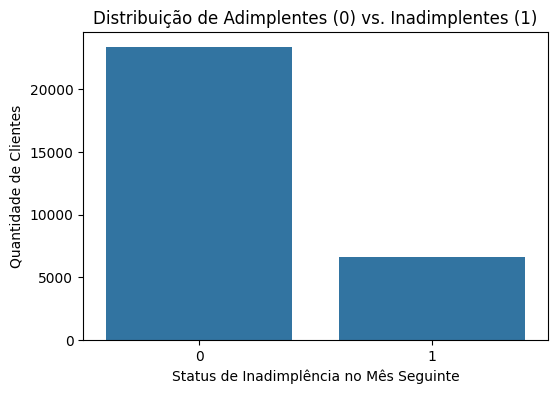

In [47]:
# 3. Distribuição da Variável-Alvo (Classificação)
target_col = 'default.payment.next.month' if 'default.payment.next.month' in df.columns else 'default_payment_next_month'

print(f"\n--- Distribuição da Variável Alvo ({target_col}) ---")
dist_target = df[target_col].value_counts(normalize=True) * 100
print(dist_target)

# Gráfico da distribuição da variável alvo
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x=target_col)
plt.title('Distribuição de Adimplentes (0) vs. Inadimplentes (1)')
plt.xlabel('Status de Inadimplência no Mês Seguinte')
plt.ylabel('Quantidade de Clientes')
plt.show()

In [48]:
from sklearn.model_selection import train_test_split

# 1. Remover a coluna ID
if 'ID' in df.columns:
    df = df.drop(columns=['ID'])
    print("✂️ Coluna 'ID' removida com sucesso!")

# 2. Inspecionar categorias nas colunas qualitativas
print("\n--- Categorias em EDUCATION ---")
print(df['EDUCATION'].value_counts())

print("\n--- Categorias em MARRIAGE ---")
print(df['MARRIAGE'].value_counts())

# 3. Separar Variáveis Explicativas (X) e Alvo (y)
X = df.drop(columns=[target_col])
y = df[target_col]

# 4. Divisão 'Sagrada' de Treino (80%) e Teste (20%) com Estratificação
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.20, 
    random_state=42, 
    stratify=y  # Garante a proporção de 78/22 em ambos os conjuntos
)

print(f"\nDivisão concluída sem Data Leakage:")
print(f"Conjunto de Treino: {X_train.shape[0]} amostras")
print(f"Conjunto de Teste:  {X_test.shape[0]} amostras")
print(f"Proporção de inadimplentes no Treino: {y_train.mean():.2%}")
print(f"Proporção de inadimplentes no Teste:  {y_test.mean():.2%}")

✂️ Coluna 'ID' removida com sucesso!

--- Categorias em EDUCATION ---
EDUCATION
2    14030
1    10585
3     4917
5      280
4      123
6       51
0       14
Name: count, dtype: int64

--- Categorias em MARRIAGE ---
MARRIAGE
2    15964
1    13659
3      323
0       54
Name: count, dtype: int64

Divisão concluída sem Data Leakage:
Conjunto de Treino: 24000 amostras
Conjunto de Teste:  6000 amostras
Proporção de inadimplentes no Treino: 22.12%
Proporção de inadimplentes no Teste:  22.12%


In [49]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# 1. Limpeza/Ajuste das categorias não documentadas (no X_train e X_test)
def limpar_categorias(df_input):
    df_clean = df_input.copy()
    # Mapear 0, 5, 6 em EDUCATION para 4 (Outros)
    df_clean['EDUCATION'] = df_clean['EDUCATION'].replace({0: 4, 5: 4, 6: 4})
    # Mapear 0 em MARRIAGE para 3 (Outros)
    df_clean['MARRIAGE'] = df_clean['MARRIAGE'].replace({0: 3})
    return df_clean

X_train_clean = limpar_categorias(X_train)
X_test_clean = limpar_categorias(X_test)

# 2. Mapeamento das colunas por tipo
num_cols = ['LIMIT_BAL', 'AGE', 
            'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6',
            'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6']

cat_cols = ['SEX', 'EDUCATION', 'MARRIAGE', 
            'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']

# 3. Construção do ColumnTransformer (Preprocessador)
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols)
    ]
)

print("⚙️ ColumnTransformer configurado com sucesso!")
print(f"Colunas Numéricas ({len(num_cols)}): {num_cols[:3]}...")
print(f"Colunas Categóricas ({len(cat_cols)}): {cat_cols[:3]}...")

⚙️ ColumnTransformer configurado com sucesso!
Colunas Numéricas (14): ['LIMIT_BAL', 'AGE', 'BILL_AMT1']...
Colunas Categóricas (9): ['SEX', 'EDUCATION', 'MARRIAGE']...


⏳ Treinando a Regressão Logística...
✅ Modelo treinado com sucesso!

--- Relatório de Classificação (Conjunto de Teste) ---
                  precision    recall  f1-score   support

  Adimplente (0)       0.87      0.84      0.85      4673
Inadimplente (1)       0.49      0.56      0.52      1327

        accuracy                           0.78      6000
       macro avg       0.68      0.70      0.69      6000
    weighted avg       0.79      0.78      0.78      6000

ROC-AUC Score: 0.7585


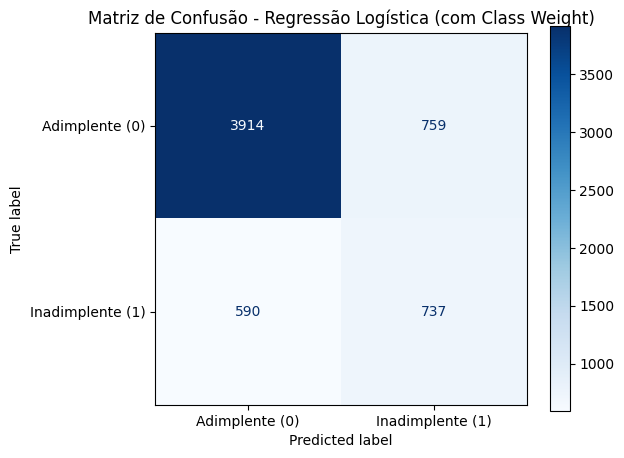

In [50]:
#Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# 1. Montar o Pipeline Completo (Pré-processamento + Regressão Logística)
pipeline_lr = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced'))
])

# 2. Treinar o modelo utilizando APENAS os dados de treino
print("⏳ Treinando a Regressão Logística...")
pipeline_lr.fit(X_train_clean, y_train)
print("✅ Modelo treinado com sucesso!")

# 3. Fazer predições no conjunto de TESTE (intocado durante o treino)
y_pred_lr = pipeline_lr.predict(X_test_clean)
y_proba_lr = pipeline_lr.predict_proba(X_test_clean)[:, 1]

# 4. Avaliação de Desempenho
print("\n--- Relatório de Classificação (Conjunto de Teste) ---")
print(classification_report(y_test, y_pred_lr, target_names=['Adimplente (0)', 'Inadimplente (1)']))

roc_auc = roc_auc_score(y_test, y_proba_lr)
print(f"ROC-AUC Score: {roc_auc:.4f}")

# 5. Plotar a Matriz de Confusão
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test, 
    y_pred_lr, 
    display_labels=['Adimplente (0)', 'Inadimplente (1)'],
    cmap=plt.cm.Blues,
    ax=ax
)
plt.title('Matriz de Confusão - Regressão Logística (com Class Weight)')
plt.show()

⏳ Treinando o KNN Classifier (K=5)...
✅ KNN treinado com sucesso!

     COMPARAÇÃO DE MODELOS (CONJUNTO DE TESTE)
 Regressão Logística -> ROC-AUC: 0.7585
 KNN (K=5)           -> ROC-AUC: 0.6988

--- Relatório de Classificação do KNN (K=5) ---
                  precision    recall  f1-score   support

  Adimplente (0)       0.83      0.93      0.88      4673
Inadimplente (1)       0.56      0.33      0.42      1327

        accuracy                           0.79      6000
       macro avg       0.70      0.63      0.65      6000
    weighted avg       0.77      0.79      0.77      6000



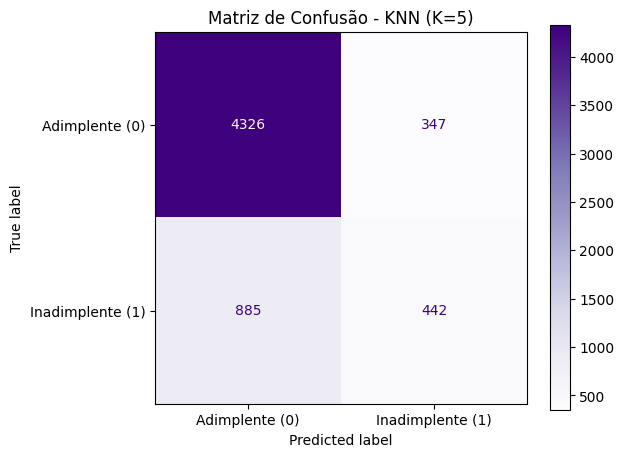

In [51]:
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, roc_auc_score, ConfusionMatrixDisplay

# 1. Garantir que a ROC-AUC da Regressão Logística seja calculada
y_proba_lr = pipeline_lr.predict_proba(X_test_clean)[:, 1]
auc_lr = roc_auc_score(y_test, y_proba_lr)

# 2. Criar e Treinar o Pipeline com KNN (K=5)
pipeline_knn = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', KNeighborsClassifier(n_neighbors=5))
])

print("⏳ Treinando o KNN Classifier (K=5)...")
pipeline_knn.fit(X_train_clean, y_train)
print("✅ KNN treinado com sucesso!")

# 3. Avaliação no Conjunto de Teste Isolado
y_pred_knn = pipeline_knn.predict(X_test_clean)
y_proba_knn = pipeline_knn.predict_proba(X_test_clean)[:, 1]

auc_knn = roc_auc_score(y_test, y_proba_knn)

print("\n" + "="*50)
print("     COMPARAÇÃO DE MODELOS (CONJUNTO DE TESTE)")
print("="*50)
print(f" Regressão Logística -> ROC-AUC: {auc_lr:.4f}")
print(f" KNN (K=5)           -> ROC-AUC: {auc_knn:.4f}")
print("="*50)

print("\n--- Relatório de Classificação do KNN (K=5) ---")
print(classification_report(y_test, y_pred_knn, target_names=['Adimplente (0)', 'Inadimplente (1)']))

# 4. Matriz de Confusão do KNN
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test, 
    y_pred_knn, 
    display_labels=['Adimplente (0)', 'Inadimplente (1)'],
    cmap='Purples',
    ax=ax
)
plt.title('Matriz de Confusão - KNN (K=5)')
plt.show()

   REGRESSÃO LOGÍSTICA: VARREDURA DE LIMIARES DE DECISÃO (τ)


,Limiar (τ),Recall (Inadimplentes),Precisão (Inadimplentes),F1-Score (Inadimplentes),Acurácia Global
0,0.20,0.9872,0.2326,0.3765,0.2770
1,0.30,0.9171,0.2674,0.4140,0.4258
2,0.35,0.8109,0.3076,0.4460,0.5545
3,0.42,0.6579,0.3970,0.4952,0.7033
4,0.50,0.5554,0.4926,0.5221,0.7752



   RELATÓRIO DETALHADO DE ALTA PROTEÇÃO (τ = 0.2)
                  precision    recall  f1-score   support

  Adimplente (0)       0.95      0.08      0.14      4673
Inadimplente (1)       0.23      0.99      0.38      1327

        accuracy                           0.28      6000
       macro avg       0.59      0.53      0.26      6000
    weighted avg       0.79      0.28      0.19      6000



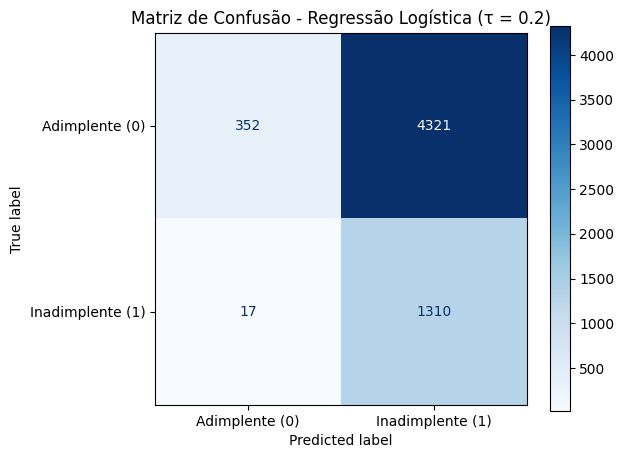

In [52]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

# 1. Obter as probabilidades preditas de inadimplência da Regressão Logística
y_proba_lr = pipeline_lr.predict_proba(X_test_clean)[:, 1]

# 2. Testar múltiplos limiares de decisão (τ) conforme metodologia de Shiv et al.
limiares = [0.20, 0.30, 0.35, 0.42, 0.50]
resultados_limiares = []

for tau in limiares:
    y_pred_tau = (y_proba_lr >= tau).astype(int)
    report = classification_report(y_test, y_pred_tau, output_dict=True)
    
    resultados_limiares.append({
        'Limiar (τ)': tau,
        'Recall (Inadimplentes)': round(report['1']['recall'], 4),
        'Precisão (Inadimplentes)': round(report['1']['precision'], 4),
        'F1-Score (Inadimplentes)': round(report['1']['f1-score'], 4),
        'Acurácia Global': round(report['accuracy'], 4)
    })

df_limiares = pd.DataFrame(resultados_limiares)

print("="*65)
print("   REGRESSÃO LOGÍSTICA: VARREDURA DE LIMIARES DE DECISÃO (τ)")
print("="*65)
display(df_limiares)

# 3. Exibir o Relatório para o Limiar de Alta Proteção (τ = 0.20)
limiar_foco = 0.20
y_pred_foco = (y_proba_lr >= limiar_foco).astype(int)

print("\n" + "="*50)
print(f"   RELATÓRIO DETALHADO DE ALTA PROTEÇÃO (τ = {limiar_foco})")
print("="*50)
print(classification_report(y_test, y_pred_foco, target_names=['Adimplente (0)', 'Inadimplente (1)']))

# 4. Plotar a Matriz de Confusão para o Limiar τ = 0.20
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test, 
    y_pred_foco, 
    display_labels=['Adimplente (0)', 'Inadimplente (1)'],
    cmap='Blues',
    ax=ax
)
plt.title(f'Matriz de Confusão - Regressão Logística (τ = {limiar_foco})')
plt.show()

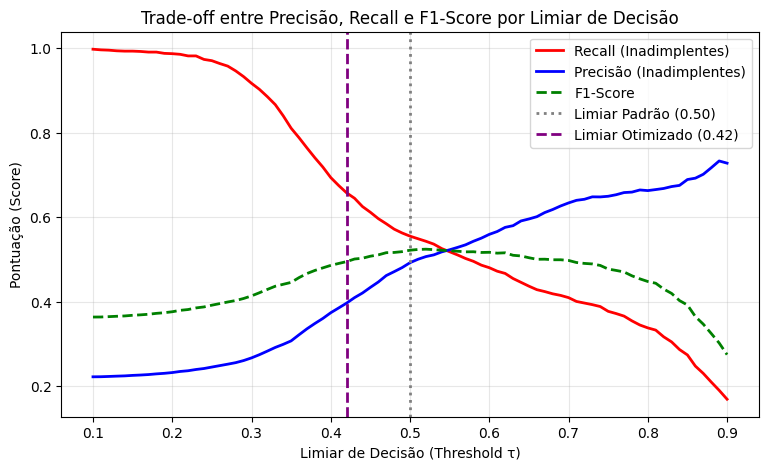


   AVALIAÇÃO COM LIMIAR OTIMIZADO UTILIZADO (τ = 0.42)
                  precision    recall  f1-score   support

  Adimplente (0)       0.88      0.72      0.79      4673
Inadimplente (1)       0.40      0.66      0.50      1327

        accuracy                           0.70      6000
       macro avg       0.64      0.69      0.64      6000
    weighted avg       0.77      0.70      0.72      6000



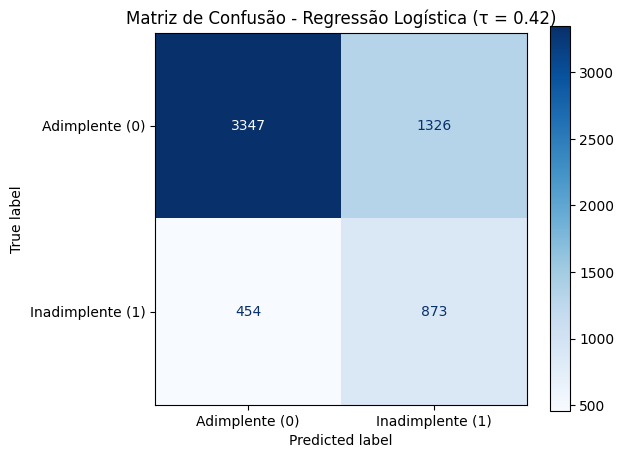

In [53]:
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

# 1. Obter probabilidades da classe positiva (Inadimplente = 1)
y_proba_lr = pipeline_lr.predict_proba(X_test_clean)[:, 1]

# 2. Testar uma faixa de limiares de 0.10 a 0.90
thresholds = np.linspace(0.1, 0.9, 81)
recalls = []
precisions = []
f1_scores = []

for t in thresholds:
    y_pred_t = (y_proba_lr >= t).astype(int)
    report = classification_report(
        y_test, 
        y_pred_t, 
        target_names=['Adimplente (0)', 'Inadimplente (1)'], 
        output_dict=True, 
        zero_division=0
    )
    recalls.append(report['Inadimplente (1)']['recall'])
    precisions.append(report['Inadimplente (1)']['precision'])
    f1_scores.append(report['Inadimplente (1)']['f1-score'])

# 3. Plotar a curva de Trade-off (Precisão vs Recall vs F1) com τ = 0.50 e τ = 0.42
plt.figure(figsize=(9, 5))
plt.plot(thresholds, recalls, label='Recall (Inadimplentes)', color='red', linewidth=2)
plt.plot(thresholds, precisions, label='Precisão (Inadimplentes)', color='blue', linewidth=2)
plt.plot(thresholds, f1_scores, label='F1-Score', color='green', linestyle='--', linewidth=2)

# Linhas verticais indicando o Limiar Padrão (0.50) e o Limiar Otimizado Utilizado (0.42)
plt.axvline(x=0.50, color='gray', linestyle=':', linewidth=2, label='Limiar Padrão (0.50)')
plt.axvline(x=0.42, color='purple', linestyle='--', linewidth=2, label='Limiar Otimizado (0.42)')

plt.title('Trade-off entre Precisão, Recall e F1-Score por Limiar de Decisão')
plt.xlabel('Limiar de Decisão (Threshold τ)')
plt.ylabel('Pontuação (Score)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# 4. Avaliar com o Limiar Otimizado Utilizado (τ = 0.42)
limiar_utilizado = 0.42
y_pred_custom = (y_proba_lr >= limiar_utilizado).astype(int)

print("\n" + "="*50)
print(f"   AVALIAÇÃO COM LIMIAR OTIMIZADO UTILIZADO (τ = {limiar_utilizado})")
print("="*50)
print(classification_report(y_test, y_pred_custom, target_names=['Adimplente (0)', 'Inadimplente (1)']))

# 5. Plotar a Matriz de Confusão para τ = 0.42
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test, 
    y_pred_custom, 
    display_labels=['Adimplente (0)', 'Inadimplente (1)'],
    cmap='Blues',
    ax=ax
)
plt.title(f'Matriz de Confusão - Regressão Logística (τ = {limiar_utilizado})')
plt.show()


⏳ Treinando modelos de Regressão...
✅ Modelos treinados com sucesso!

       COMPARAÇÃO DE MODELOS DE REGRESSÃO (TESTE)


,Modelo,MAE,RMSE,R²
0,Regressão Linear Múltipla,8166.125933,19653.821928,0.93051
1,Regressão Ridge (L2),8154.304935,19619.867778,0.93075


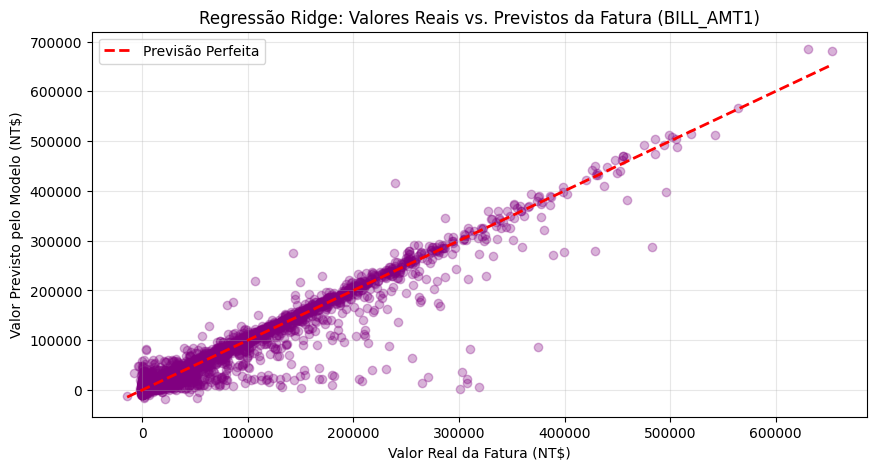

In [55]:
# Regressão

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline

# 1. Definição do Problema de Regressão
# Target (y_reg): BILL_AMT1 (Valor da fatura atual em risco)
target_reg = 'BILL_AMT1'

# Remover o target de regressão e o target de classificação das variáveis explicativas
X_reg = df.drop(columns=[target_reg, target_col])
y_reg = df[target_reg]

# 2. Reorganizar as colunas numéricas e categóricas sem a BILL_AMT1
num_cols_reg = [col for col in num_cols if col != target_reg]
cat_cols_reg = cat_cols.copy()

# 3. Preprocessador dedicado para a Regressão
preprocessor_reg = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols_reg),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols_reg)
    ]
)

# 4. Divisão de Treino (80%) e Teste (20%) para Regressão
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg, y_reg, test_size=0.20, random_state=42
)

# Ajustar categorias não documentadas
X_train_reg_clean = limpar_categorias(X_train_reg)
X_test_reg_clean = limpar_categorias(X_test_reg)

# 5. Criar e Treinar os dois Pipelines de Regressão
pipeline_lr_reg = Pipeline([
    ('preprocessor', preprocessor_reg),
    ('regressor', LinearRegression())
])

pipeline_ridge_reg = Pipeline([
    ('preprocessor', preprocessor_reg),
    ('regressor', Ridge(alpha=10.0))
])

print("⏳ Treinando modelos de Regressão...")
pipeline_lr_reg.fit(X_train_reg_clean, y_train_reg)
pipeline_ridge_reg.fit(X_train_reg_clean, y_train_reg)
print("✅ Modelos treinados com sucesso!")

# 6. Predições no Conjunto de Teste
y_pred_lr_reg = pipeline_lr_reg.predict(X_test_reg_clean)
y_pred_ridge_reg = pipeline_ridge_reg.predict(X_test_reg_clean)

# 7. Função para calcular as métricas exigidas (MAE, RMSE, R²)
def calcular_metricas(y_true, y_pred, nome_modelo):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    return {'Modelo': nome_modelo, 'MAE': mae, 'RMSE': rmse, 'R²': r2}

res_lr = calcular_metricas(y_test_reg, y_pred_lr_reg, 'Regressão Linear Múltipla')
res_ridge = calcular_metricas(y_test_reg, y_pred_ridge_reg, 'Regressão Ridge (L2)')

df_resultados_reg = pd.DataFrame([res_lr, res_ridge])

print("\n" + "="*60)
print("       COMPARAÇÃO DE MODELOS DE REGRESSÃO (TESTE)")
print("="*60)
display(df_resultados_reg)

# 8. Gráfico de Diagnóstico de Resíduos (Valores Reais vs Previstos)
plt.figure(figsize=(10, 5))
plt.scatter(y_test_reg, y_pred_ridge_reg, alpha=0.3, color='purple')
plt.plot([y_test_reg.min(), y_test_reg.max()], [y_test_reg.min(), y_test_reg.max()], 'r--', lw=2, label='Previsão Perfeita')
plt.title('Regressão Ridge: Valores Reais vs. Previstos da Fatura (BILL_AMT1)')
plt.xlabel('Valor Real da Fatura (NT$)')
plt.ylabel('Valor Previsto pelo Modelo (NT$)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()